# Análise temporal de períodos de seca em Pernambuco
### Projeto Final Introdução à Ciência de Dados (2026.1)

**Integrantes:** Henrique Jales, Mikael Rodrigues, Gabriel Lopes, Pedro Borras Souto


## 1. Introdução

O semiárido pernambucano convive historicamente com secas que ameaçam a agricultura de
subsistência e o abastecimento de água. Entender como o clima do estado vem se comportando ao
longo das últimas décadas está mais quente? mais seco? quais regiões sofrem mais? é o
objetivo deste trabalho

Analisamos dados meteorológicos diários de 6 municípios que representam 4 mesorregiões de
Pernambuco (Recife/Metropolitana, Caruaru e Garanhuns/Agreste, Serra Talhada e Salgueiro/Sertão,
Petrolina/São Francisco), de 1970 a 2026

Para medir a seca de forma comparável entre cidades usamos o SPI (Standardized Precipitation
Index, Índice Padronizado de Precipitação). O SPI compara a chuva de um período com o histórico do
próprio local e devolve um número padronizado: valores negativos indicam chuva abaixo do normal
(seca) e positivos, acima do normal. Por ser padronizado, ele permite comparar diretamente
regiões de climas distintos como o sertão e o litoral, o que seria impossível olhando apenas os
milímetros de chuva. O cálculo é feito pela biblioteca spei, a partir dele produzimos a tabela de eventos de seca

### Perguntas investigadas
1. Pernambuco está esquentando?
2. Está ficando mais seco?
3. Quais cidades sofrem mais secas, e de que gravidade?
4. As 6 cidades formam tipos de clima distintos?
5. Qual a sazonalidade da chuva ao longo do ano?


## Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ordem das classificações de severidade
SEV_ORDER = ['Seca Moderada', 'Seca Severa', 'Seca Extrema']

# Mapa de cidades para suas respectivas mesorregiões
MESORREGIAO = {
    'Recife': 'Metropolitana', 'Caruaru': 'Agreste', 'Garanhuns': 'Agreste',
    'Serra Talhada': 'Sertão', 'Salgueiro': 'Sertão', 'Petrolina': 'São Francisco',
}

## Carregamento dos dados

In [2]:
mensal = pd.read_csv('../data/processed/dados_mensais.csv')
eventos = pd.read_csv('../data/processed/eventos_seca.csv')
mensal['data'] = pd.to_datetime(mensal['data'])
print('Período:', mensal['data'].min().date(), '|', mensal['data'].max().date())
print('Municípios:', ', '.join(sorted(mensal['municipio'].unique())))
mensal.info()

Período: 1970-01-01 | 2026-06-01
Municípios: Caruaru, Garanhuns, Petrolina, Recife, Salgueiro, Serra Talhada
<class 'pandas.DataFrame'>
RangeIndex: 4068 entries, 0 to 4067
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            4068 non-null   datetime64[us]
 1   municipio       4068 non-null   str           
 2   precip_mm       4068 non-null   float64       
 3   temp_max_c      4068 non-null   float64       
 4   temp_min_c      4068 non-null   float64       
 5   temp_media_c    4068 non-null   float64       
 6   evapo_mm        4068 non-null   float64       
 7   dias_sem_chuva  4068 non-null   int64         
 8   n_dias          4068 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(2), str(1)
memory usage: 286.2 KB


In [3]:
mensal.describe().drop(columns='data').round(1)

,precip_mm,temp_max_c,temp_min_c,temp_media_c,evapo_mm,dias_sem_chuva,n_dias
count,4068.0,4068.0,4068.0,4068.0,4068.0,4068.0,4068.0
mean,51.1,29.5,21.0,24.8,147.4,19.9,30.4
min,0.0,20.3,15.4,17.8,28.6,0.0,13.0
25%,10.0,27.5,19.2,23.1,117.6,13.0,30.0
50%,33.2,29.4,21.1,24.8,143.5,21.0,31.0
75%,70.1,31.6,22.8,26.7,171.1,28.0,31.0
max,581.7,36.6,25.8,30.9,259.6,31.0,31.0
std,58.6,3.1,2.2,2.6,40.4,8.4,1.1


In [4]:
eventos.describe().round(1)

,duracao_meses,spi_minimo
count,137.0,137.0
mean,3.7,-2.0
std,2.2,0.6
min,2.0,-3.5
25%,2.0,-2.5
50%,3.0,-1.9
75%,4.0,-1.5
max,15.0,-1.1


## Pré-processamento

A limpeza pesada (interpolação de lacunas, agregação diária para mensal e cálculo do SPI) já foi feita, agora partimos dos arquivos de data/processed/ e so falta:

- extrair mes e ano da data
- remover 2026 das análises anuais, os dados vão só até jun/2026 (ano incompleto), o que
  enviesaria somas e médias anuais
- anexar a mesorregião de cada cidade para comparações


In [5]:
mensal['ano'] = mensal['data'].dt.year
mensal['mes'] = mensal['data'].dt.month
mensal['mesorregiao'] = mensal['municipio'].map(MESORREGIAO)
print("Mensal colunas:", mensal.columns.tolist())

anual_base = mensal[mensal['ano'] < 2026].copy()
CIDADES = sorted(mensal['municipio'].unique())
print('Anos completos:', anual_base['ano'].min(), '|', anual_base['ano'].max())

Mensal colunas: ['data', 'municipio', 'precip_mm', 'temp_max_c', 'temp_min_c', 'temp_media_c', 'evapo_mm', 'dias_sem_chuva', 'n_dias', 'ano', 'mes', 'mesorregiao']
Anos completos: 1970 | 2025


## Pernambuco está esquentando?

Ajustamos uma regressão linear da temperatura média anual contra o ano para cada cidade, e
usamos o coeficiente angular (°C por década) e o p-valor para dizer se a tendência é real.


In [6]:
# Para cada cidade, ajustamos uma reta da temperatura média ao longo dos anos
# slope = quanto a temperatura sobe por ano, p_valor < 0,05 indica tendência real
temp_anual = anual_base.groupby(['municipio', 'ano'])['temp_media_c'].mean().reset_index()

resultados = []
for cidade in CIDADES:
    dados_cidade = temp_anual[temp_anual['municipio'] == cidade]
    reta = linregress(dados_cidade['ano'], dados_cidade['temp_media_c'])
    resultados.append({
        'municipio': cidade,
        'tend_C_por_decada': reta.slope * 10, # variação por década
        'p_valor': reta.pvalue,
    })

reg_temp = pd.DataFrame(resultados).sort_values('tend_C_por_decada', ascending=False)
reg_temp.round(3)

,municipio,tend_C_por_decada,p_valor
2,Petrolina,0.169,0.000
3,Recife,0.112,0.000
4,Salgueiro,0.054,0.267
5,Serra Talhada,0.026,0.576
1,Garanhuns,0.007,0.762
0,Caruaru,-0.084,0.011


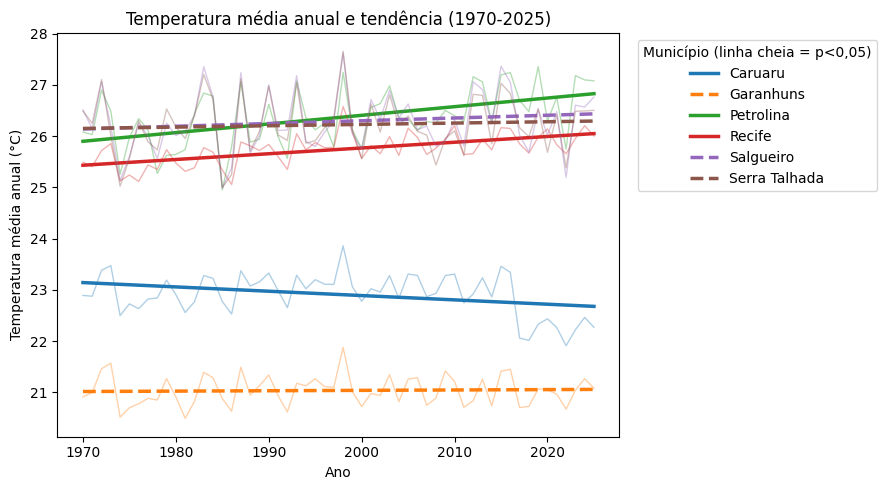

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for cidade in CIDADES:
    dados_cidade = temp_anual[temp_anual['municipio'] == cidade]

    # pontos observados (linha fina)
    linha, = ax.plot(dados_cidade['ano'], dados_cidade['temp_media_c'], lw=1, alpha=0.35)

    # reta de tendência (linha grossa) sólida se significativa (p < 0,05) se não tracejada
    reta = linregress(dados_cidade['ano'], dados_cidade['temp_media_c'])
    anos = np.array([dados_cidade['ano'].min(), dados_cidade['ano'].max()])
    estilo = '-' if reta.pvalue < 0.05 else '--'
    ax.plot(anos, reta.intercept + reta.slope * anos, color=linha.get_color(), lw=2.5, ls=estilo, label=cidade)

ax.set(xlabel='Ano', ylabel='Temperatura média anual (°C)', title='Temperatura média anual e tendência (1970-2025)')
ax.legend(title='Município (linha cheia = p<0,05)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

O aquecimento não é uniforme. Ele é estatisticamente significativo e
mais forte em Petrolina e Recife. Nas demais a tendência é fraca e não
significativa, Caruaru chega a mostrar leve queda. 

Ou seja: partes de Pernambuco esquentam claramente


## Está ficando mais seco?

Mesma ideia da anterior, agora com a precipitação total anual (soma dos 12 meses) por cidade.


In [8]:
# Mesma ideia da 1, agora com a chuva total do ano soma dos 12 meses
# slope < 0 chuva diminuindo ao longo dos anos
precip_anual = anual_base.groupby(['municipio', 'ano'])['precip_mm'].sum().reset_index()

resultados = []
for cidade in CIDADES:
    dados_cidade = precip_anual[precip_anual['municipio'] == cidade]
    reta = linregress(dados_cidade['ano'], dados_cidade['precip_mm'])
    resultados.append({
        'municipio': cidade,
        'tend_mm_por_decada': reta.slope * 10,
        'p_valor': reta.pvalue,
    })

reg_precip = pd.DataFrame(resultados).sort_values('tend_mm_por_decada')
reg_precip.round(3)

,municipio,tend_mm_por_decada,p_valor
4,Salgueiro,-51.769,0.009
5,Serra Talhada,-38.142,0.064
2,Petrolina,-16.759,0.263
0,Caruaru,12.887,0.413
1,Garanhuns,35.850,0.042
3,Recife,55.441,0.026


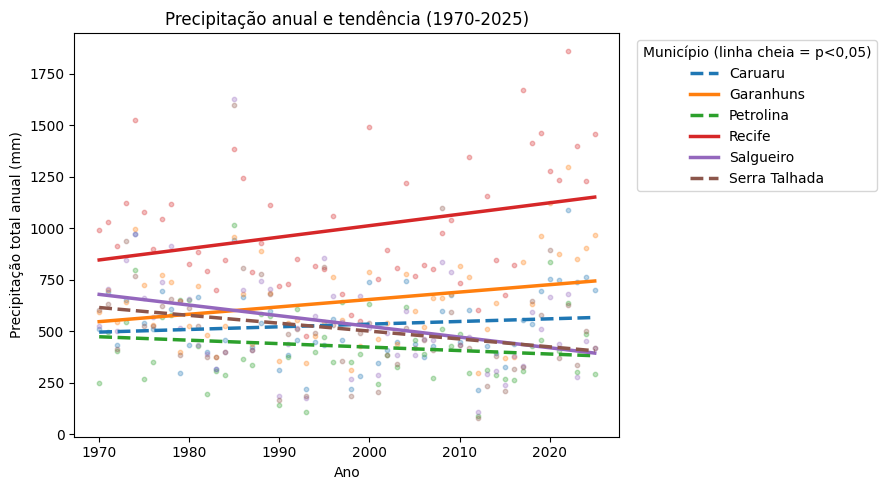

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
for cidade in CIDADES:
    dados_cidade = precip_anual[precip_anual['municipio'] == cidade]

    # chuva de cada ano (pontos)
    pontos = ax.scatter(dados_cidade['ano'], dados_cidade['precip_mm'], s=10, alpha=0.3)
    cor = pontos.get_facecolor()[0][:3]

    # reta de tendência sólida se significativa
    reta = linregress(dados_cidade['ano'], dados_cidade['precip_mm'])
    anos = np.array([dados_cidade['ano'].min(), dados_cidade['ano'].max()])
    estilo = '-' if reta.pvalue < 0.05 else '--'
    ax.plot(anos, reta.intercept + reta.slope * anos, color=cor, lw=2.5, ls=estilo, label=cidade)

ax.set(xlabel='Ano', ylabel='Precipitação total anual (mm)', title='Precipitação anual e tendência (1970-2025)')
ax.legend(title='Município (linha cheia = p<0,05)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

Também há contraste regional, e em direções opostas. No sertão a
chuva diminui de forma significativa Salgueiro e quase significativa em
Serra Talhada, já o litoral e o agreste ficam mais úmidos Recife e
Garanhuns sobem com significância. Então a resposta é: o sertão
tende a secar enquanto as regiões mais úmidas recebem mais chuva, o que agrava o contraste
climático do estado.


## Quais cidades sofrem mais secas?

Usamos a tabela eventos_seca.csv (137 eventos, cada um um período com SPI ≤ −1,0), contando
eventos por cidade e gravidade (Moderada / Severa / Extrema) num gráfico de barras
empilhadas.


In [10]:
# Conta os eventos de cada cidade, separados por gravidade
contagem = eventos.groupby(['municipio', 'classificacao']).size().unstack(fill_value=0)

# Coloca as colunas de gravidade na ordem certa (Moderada, Severa, Extrema)
contagem = contagem[SEV_ORDER]

# Ordena as cidades da que teve mais eventos para a que teve menos
contagem['total'] = contagem.sum(axis=1)
contagem = contagem.sort_values('total', ascending=False).drop(columns='total')
contagem

classificacao,Seca Moderada,Seca Severa,Seca Extrema
municipio,,,
Salgueiro,6,10,10
Petrolina,2,10,12
Serra Talhada,5,6,13
Garanhuns,6,6,10
Recife,6,7,9
Caruaru,5,6,8


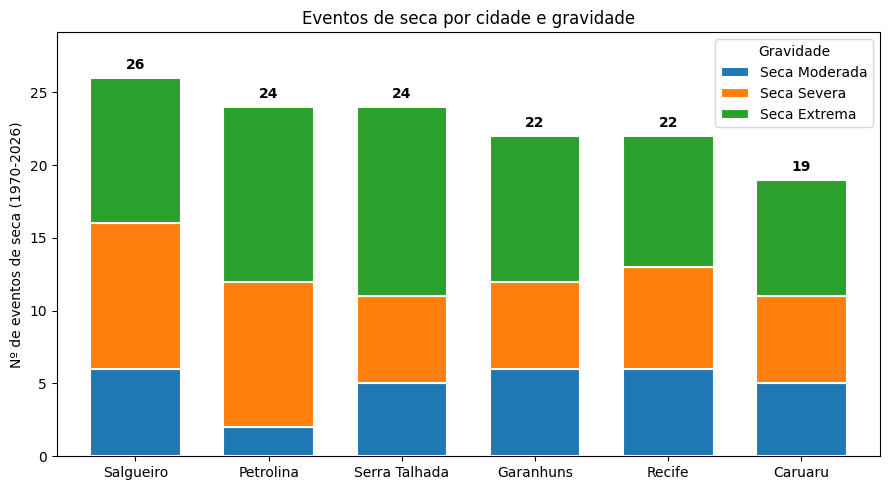

In [11]:
# Cria o gráfico de barras empilhadas
ax = contagem.plot.bar(stacked=True, figsize=(9, 5), width=0.68, edgecolor='white', linewidth=1.5, rot=0)

# escreve o total em cima de cada barra
for i, total in enumerate(contagem.sum(axis=1)):
    ax.text(i, total + 0.4, int(total), ha='center', va='bottom', fontweight='bold')

ax.set(xlabel='', ylabel='Nº de eventos de seca (1970-2026)', title='Eventos de seca por cidade e gravidade')
ax.legend(title='Gravidade'); ax.margins(y=0.12)
plt.tight_layout(); plt.show()

As cidades do sertão e do São Francisco lideram: Salgueiro (26
eventos), Serra Talhada (24) e Petrolina (24) acumulam mais secas, e também as mais
graves, Serra Talhada (13) e Petrolina (12) têm o maior número de secas extremas. Caruaru
(19), no agreste mais ameno, é a menos atingida. O padrão confirma a vulnerabilidade do
semiárido e conversa com a queda das chuvas


## As cidades formam tipos de clima distintos?

Descrevemos cada cidade por 4 características médias (precipitação anual, temperatura média,
evapotranspiração anual e dias sem chuva por mês), padronizamos com StandardScaler e
agrupamos com KMeans. Escolhemos o número de grupos k pela silhueta.


In [12]:
# Descreve cada cidade por 4 números médios
# precip_mm e evapo_mm são mensais média mensal x 12 = total anual
perfil = anual_base.groupby('municipio').agg(
    precip_anual = ('precip_mm', 'mean'),
    temp_media = ('temp_media_c', 'mean'),
    evapo_anual = ('evapo_mm', 'mean'),
    dias_sem_chuva = ('dias_sem_chuva', 'mean'),
)
perfil['precip_anual'] = perfil['precip_anual'] * 12
perfil['evapo_anual'] = perfil['evapo_anual'] * 12

# Padroniza (média 0, desvio 1) para as 4 características terem o mesmo peso
X = StandardScaler().fit_transform(perfil)

# Testa alguns valores de k e imprime a silhueta de cada um quanto maior melhor
for k in [2, 3, 4]:
    grupos = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)
    print(f'k={k} silhueta={silhouette_score(X, grupos)}')

k=2 silhueta=0.5857627907991062
k=3 silhueta=0.6325580895504536
k=4 silhueta=0.4161540836367383


In [13]:
k = 3  # k com a melhor silhueta
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)

# Guarda em qual grupo cada cidade caiu e a sua mesorregião, para comparar depois
perfil['cluster'] = km.labels_
perfil['mesorregiao'] = perfil.index.map(MESORREGIAO)
perfil.round(1)

,precip_anual,temp_media,evapo_anual,dias_sem_chuva,cluster,mesorregiao
municipio,,,,,,
Caruaru,531.6,22.9,1482.2,18.2,2,Agreste
Garanhuns,645.5,21.0,1438.1,16.3,2,Agreste
Petrolina,427.5,26.4,2132.0,25.7,0,São Francisco
Recife,998.6,25.7,1505.3,10.2,1,Metropolitana
Salgueiro,536.7,26.3,2035.8,24.5,0,Sertão
Serra Talhada,510.5,26.2,2033.5,24.9,0,Sertão


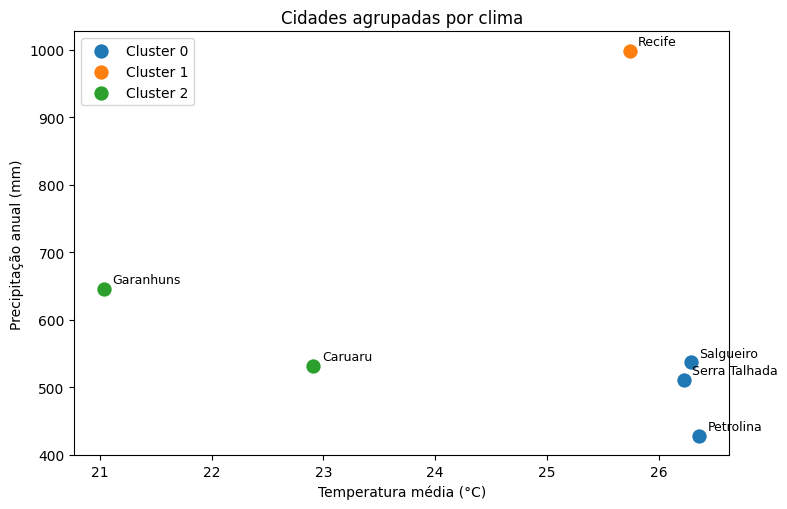

In [14]:
fig, ax1 = plt.subplots(figsize=(8, 5.2))

# cada cidade como um ponto em temperatura x precipitação, colorido pelo seu grupo
for cluster in sorted(perfil['cluster'].unique()):
    cidades_grupo = perfil[perfil['cluster'] == cluster]
    ax1.scatter(cidades_grupo['temp_media'], cidades_grupo['precip_anual'], s=140,
                edgecolor='white', linewidth=1.5, label=f'Cluster {cluster}')
# escreve o nome de cada cidade ao lado do seu ponto
for cidade in perfil.index:
    ax1.annotate(cidade, (perfil.loc[cidade, 'temp_media'], perfil.loc[cidade, 'precip_anual']), xytext=(6, 4), textcoords='offset points', fontsize=9)
ax1.set(xlabel='Temperatura média (°C)', ylabel='Precipitação anual (mm)', title='Cidades agrupadas por clima')
ax1.legend()
plt.tight_layout(); plt.show()

A silhueta é máxima em k=3 (0,63), e os grupos reproduzem quase
exatamente a geografia:

- Cluster do semiárido: Petrolina, Salgueiro, Serra Talhada: quentes e secos.
- Cluster litorâneo: Recife (sozinho): chuvoso e quente, com poucos dias sem chuva.
- Cluster do agreste (altitude elevada): Caruaru e Garanhuns: os mais amenos (temperatura
  abaixo da média) e de seca intermediária.

O agrupamento recupera as mesorregiões conhecidas apenas a partir do clima, validando que sertão, agreste e litoral são de fato regimes climáticos distintos


## Qual a sazonalidade da chuva?

Distribuição da precipitação mensal ao longo do ano (todos os anos sobrepostos), via
boxplot. Duas cidades opostas: Recife (litoral) e Petrolina (Sertão).


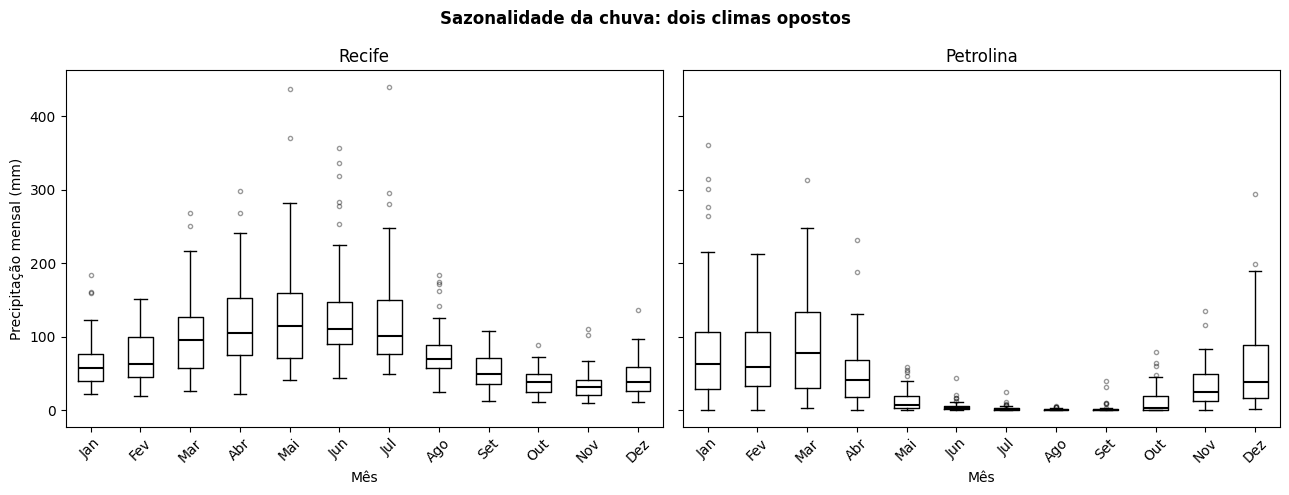

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
MESES = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

for ax, cidade in zip(axes, ['Recife', 'Petrolina']):
    # junta para cada mes os valores de chuva de todos os anos numa lista um box por mês
    dados_por_mes = []
    for numero_mes in range(1, 13):
        chuva = mensal[(mensal['municipio'] == cidade) & (mensal['mes'] == numero_mes)]['precip_mm']
        dados_por_mes.append(chuva.values)

    ax.boxplot(dados_por_mes, tick_labels=MESES,
               medianprops={'color': 'black', 'linewidth': 1.5},
               flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
    ax.set(title=f'{cidade}', xlabel='Mês')
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Precipitação mensal (mm)')
fig.suptitle('Sazonalidade da chuva: dois climas opostos', fontweight='bold')
plt.tight_layout(); plt.show()

São quase espelhados. Em Recife a estação chuvosa
é o outono/inverno (pico em maio/julho), com verão seco. Já Petrolina concentra a
chuva no verão (nov/mar) e tem um inverno extremamente seco entre maio
e setembro. Essa diferença explica por que usar SPI é indispensável:
comparar meses absolutos misturaria estações opostas.


## Conclusão

- Aquecimento: real e significativo em Petrolina e Recife, ausente ou fraco no agreste.
- Chuva: sem tendência única, o sertão seca (Salgueiro, Serra Talhada) enquanto
  litoral e agreste umedecem, ampliando o contraste climático.
- Secas: concentram-se no sertão/São Francisco (Salgueiro, Serra Talhada, Petrolina),
  também as mais graves.
- Tipos de clima: o KMeans recupera sozinho três climas semiárido, litoral e agreste coerentes com as mesorregiões.
- Sazonalidade: litoral e São Francisco têm estações chuvosas opostas, o que justifica o
  uso de um índice padronizado como o SPI.

Importância: Os resultados reforçam que a política de convivência com a seca deve priorizar o
sertão, onde menos chove.

Limitações: Os dados vêm da (Open-Meteo) e não de estações locais, podem
suavizar extremos. 6 municípios são uma amostra, não o estado inteiro

Trabalhos futuros: Incluir mais municípios, procurar fontes climáticas locais, cruzar as secas com dados de produção agrícola
(IBGE) e testar modelos de previsão sazonal do SPI.
